In [1]:
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import numpy as np
import h5py
#from common import smooth
from matplotlib.ticker import FormatStrFormatter

plt.rc('font', family='Times New Roman', size=14)
plt.rcParams['mathtext.fontset'] = 'custom'

plt.rcParams['mathtext.it'] = 'STIXGeneral:italic'
plt.rcParams['mathtext.rm'] = 'STIXGeneral:bold'
plt.rcParams['mathtext.tt'] = 'STIXGeneral'
plt.rcParams['mathtext.bf'] = 'STIXGeneral:bold:italic'
plt.rcParams['mathtext.cal'] = 'STIXGeneral'
plt.rcParams['mathtext.sf'] = 'STIXGeneral'

plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.linewidth'] = 1.5

itr = r'$R$'
ite = r'$E$'

color_dict = {'HF':'tab:gray',
              'CASSCF':'tab:gray',
              'GW':'tab:red',
              'FCI':'black'}

In [2]:
from pyscf.data.nist import HARTREE2EV as au2ev

In [3]:
from gf.gw.addons import read_spec_dat

W, dat_cas = read_spec_dat('6-31G/cas64/spec-o3-Gcas.dat')
W, dat_casgw = read_spec_dat('6-31G/cas64/spec-o3-Gcasgw.dat')

In [4]:
from scipy.signal import find_peaks

pk,_ = find_peaks(dat_cas)
print('CAS peaks'); print(W[pk])

pk,_ = find_peaks(dat_casgw)
print('GW@CAS peaks'); print(W[pk])

CAS peaks
[-0.73351648 -0.72506413 -0.69235724 -0.63539579 -0.62106355 -0.60783379
 -0.55564976 -0.53911256 -0.52845526 -0.00404243]
GW@CAS peaks
[-0.72910656 -0.7107319  -0.63208835 -0.61591864 -0.60268889 -0.53507014
 -0.47553623 -0.46487893 -0.00477741]


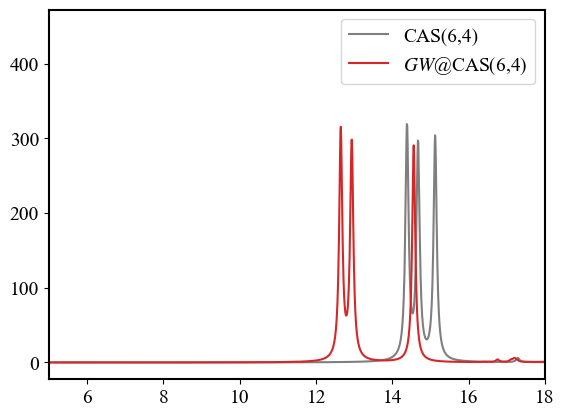

In [5]:
fig,ax = plt.subplots(nrows=1, ncols=1)

ax.plot(-W*au2ev, dat_cas, label='CAS(6,4)', color=color_dict['CASSCF'])
ax.plot(-W*au2ev, dat_casgw, label=r'$GW$@CAS(6,4)', color=color_dict['GW'])

ax.set_xlim(5,18)

ax.legend()

In [6]:

W, dat_cas = read_spec_dat('6-31G/cas66/spec-o3-Gcas.dat')
W, dat_casgw = read_spec_dat('6-31G/cas66/spec-o3-Gcasgw.dat')

pk,_ = find_peaks(dat_cas)
print('CAS peaks')
print(W[pk])
#print([w*au2ev for w in W[pk]])

pk,_ = find_peaks(dat_casgw)
print('GW@CAS peaks')
print(W[pk])
#print([w*au2ev for w in W[pk]])

CAS peaks
[-0.7158768  -0.70632198 -0.67104263 -0.63172085 -0.61775611 -0.55013736
 -0.53543763 -0.52845526 -0.01286226]
GW@CAS peaks
[-0.72102171 -0.7107319  -0.70044209 -0.67067514 -0.63098587 -0.61702112
 -0.60893627 -0.52367785 -0.47443375 -0.46892135 -0.01580221]


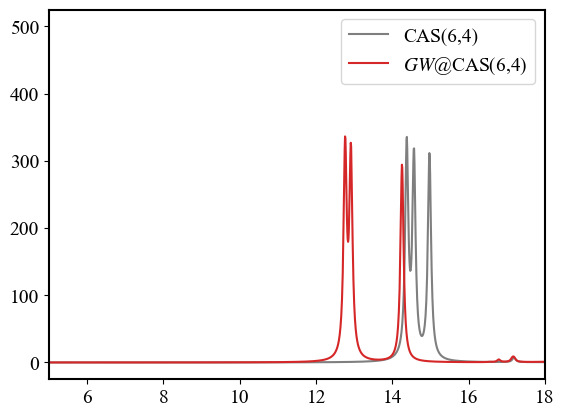

In [7]:
fig,ax = plt.subplots(nrows=1, ncols=1)

ax.plot(-W*au2ev, dat_cas, label='CAS(6,4)', color=color_dict['CASSCF'])
ax.plot(-W*au2ev, dat_casgw, label=r'$GW$@CAS(6,4)', color=color_dict['GW'])

ax.set_xlim(5,18)

ax.legend()

In [8]:

W, dat_cas = read_spec_dat('cc-pvdz/spec-o3-Gcas.dat')
W, dat_casgw = read_spec_dat('cc-pvdz/spec-o3-Gcasgw.dat')

pk,_ = find_peaks(dat_cas)
print('CAS peaks')
print(W[pk])
#print([w*au2ev for w in W[pk]])

pk,_ = find_peaks(dat_casgw)
print('GW@CAS peaks')
print(W[pk])
#print([w*au2ev for w in W[pk]])

CAS peaks
[-0.72102171 -0.678025   -0.63025088 -0.60709881 -0.59607401 -0.53764259
 -0.51890043 -0.51265305]
GW@CAS peaks
[-0.73314898 -0.72579912 -0.70338203 -0.62951589 -0.61665363 -0.59791148
 -0.59203159 -0.5258828  -0.46414394 -0.4608365 ]


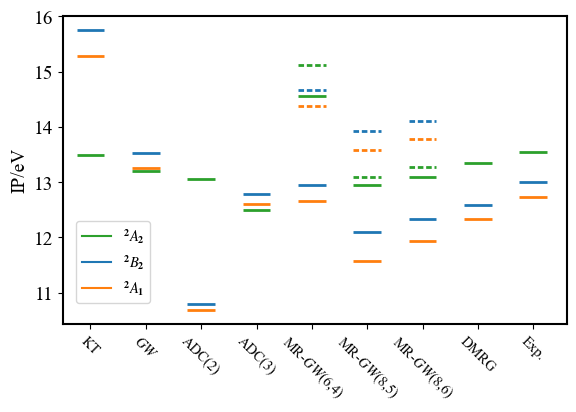

In [11]:

fig, ax = plt.subplots(figsize=(6.5, 4))


#ax.set_xlim(0, 6)
#ax.set_ylim(0, 6)

data = [[15.29, 15.76, 13.49],
        [13.25, 13.52, 13.20],
        [10.69, 10.79, 13.05],
        [12.61, 12.79, 12.49],
        #[14.38, 14.67, 15.12],
        [12.65, 12.94, 14.56],
        #[13.59, 13.92, 13.10],
        [11.58, 12.09, 12.94],
        #[13.78, 14.10, 13.28],
        [11.93, 12.33, 13.09],
        [12.34, 12.59, 13.34],#DMRG
        [12.73, 13.00, 13.54]]


method_lst = ['KT', r'$GW$', 'ADC(2)', 'ADC(3)', 
              #'CAS(6,4)', 
              r'MR-$GW$(6,4)',
              #'CAS(8,5)', 
              r'MR-$GW$(8,5)', 
              #'CAS(8,6)', 
              r'MR-$GW$(8,6)',
              'DMRG', 
              'Exp.']
num_meth = len(method_lst)

ax.set_xlim( -.5, num_meth-0.4 )
#ax.set_ylim( top=17)

ax.set_xticks( range(0, num_meth) )
ax.set_xticklabels( method_lst, rotation=-45, fontsize=10.5)

#ax.axhline(y=12.73, ls='--', color='C0')
#ax.axhline(y=13.00, ls='--', color='C1')
#ax.axhline(y=13.54, ls='--', color='C2')

#ax.axhline(y=12.73, ls='--', color='C0')
#ax.axhline(y=13.00, ls='--', color='C1')
#ax.axhline(y=13.54, ls='--', color='C2')


L = .5

for i in range(num_meth):
    a1, b2, a2 = data[i]
    ax.hlines(y=a1, xmin=i-L/2, xmax=i+L/2, colors='C1', linewidth=2)
    ax.hlines(y=b2, xmin=i-L/2, xmax=i+L/2, colors='C0', linewidth=2)
    ax.hlines(y=a2, xmin=i-L/2, xmax=i+L/2, colors='C2', linewidth=2)

data = [[14.38, 14.67, 15.12],
        [13.59, 13.92, 13.10],
        [13.78, 14.10, 13.28]]

for i,d in enumerate([4,5,6]):
    a1, b2, a2 = data[i]
    ax.hlines(y=a1, xmin=d-L/2, xmax=d+L/2, colors='C1', ls=(0,(2,1)), linewidth=2)
    ax.hlines(y=b2, xmin=d-L/2, xmax=d+L/2, colors='C0', ls=(0,(2,1)), linewidth=2)
    ax.hlines(y=a2, xmin=d-L/2, xmax=d+L/2, colors='C2', ls=(0,(2,1)), linewidth=2)

ax.plot([], [], color='C2', label=r'$^2A_2$')
ax.plot([], [], color='C0', label=r'$^2B_2$')
ax.plot([], [], color='C1', label=r'$^2A_1$')

ax.set_ylabel('IP/eV')

ax.legend(fontsize=10.5, loc="center", bbox_to_anchor=(.1,.2))

fig.savefig('O3-IP.pdf', format='pdf', bbox_inches='tight')